# 2D Navier-Stokes: ETKF

## 1. Overview

This tutorial applies the ensemble transform Kalman filter (ETKF) to a
forced, dissipative two-dimensional Navier-Stokes flow on the torus,
observed only through its low Fourier modes. It follows
`docs/notebook_spec.md`; the paired CLI script is
`examples/scripts/nse2d_etkf.py`.

## 2. Model

The vorticity form of the 2D Navier-Stokes equations on the torus
$[0, 2\pi]^2$ with viscosity $\nu$, linear drag $\gamma$, and stationary
Kolmogorov forcing $f$:

$$
\partial_t \omega + (u \cdot \nabla)\, \omega
= \nu \Delta \omega - \gamma \omega + f,
\qquad
u = \nabla^{\perp} \Delta^{-1} \omega,
\qquad
f = -k_f \cos(k_f y),
$$

with forcing wavenumber $k_f = 4$. The solver (`da.nse2d.NSE2DTorus`) is
pseudo-spectral on a $16 \times 16$ grid with 2/3 dealiasing; the DA state
$x \in \mathbb{R}^{256}$ is the packed real/imaginary `rfft2` vorticity
spectrum (`to_spectral_state`). One assimilation window advances the flow
by $\Delta t = 0.05$ using 5 internal RK4 substeps.

## 3. Observation

Only the low Fourier modes with $|k_x|, |k_y| \leq k_{\max} = 4$ are
observed (`spectral_low_mode_observation`), giving $N_y = 81$ real
observation components out of $N_x = 256$:

$$
y_k = H x_k + \varepsilon_k, \qquad
\varepsilon_k \sim N(0, R), \qquad
R = \operatorname{diag}\big(\sigma_0^2 / |k|^2\big),
$$

where the per-mode noise variance decays with the wavenumber magnitude
($\sigma_0 = 0.5$, `decay_power=1`). The observation-noise scale is
$\sigma_{\mathrm{obs}} = \sqrt{\operatorname{tr}(R)/N_y} \approx 0.18$.

## 4. DA method

The **ensemble transform Kalman filter (ETKF)** represents the forecast
uncertainty by an ensemble $X^f \in \mathbb{R}^{m \times N_x}$ with mean
$\bar{x}^f$ and anomaly matrix $A^f$ (rows $x^{f,(i)} - \bar{x}^f$).

**Forecast step:** each member is propagated by the model,
$x_k^{f,(i)} = M(x_{k-1}^{a,(i)})$.

**Analysis step:** with $\tilde{P} = \big[(m-1) I + (H A^f)^{\mathsf T}
R^{-1} (H A^f)\big]^{-1}$,

$$
\bar{x}^a = \bar{x}^f + A^f\, \tilde{P}\, (H A^f)^{\mathsf T} R^{-1}
\,(y - H \bar{x}^f),
\qquad
A^a = A^f \big[(m-1)\, \tilde{P}\big]^{1/2}.
$$

Multiplicative inflation is applied to the anomalies, $A \to \alpha A$
(covariance inflation $\alpha^2$), to compensate for sampling error.

## 5. Parameters

| Parameter | Symbol | Value |
| --- | --- | --- |
| grid | | $16 \times 16$ |
| viscosity | $\nu$ | $10^{-2}$ |
| drag | $\gamma$ | $10^{-1}$ |
| forcing mode | $k_f$ | 4 |
| assimilation window | $\Delta t$ | 0.05 (5 RK4 substeps) |
| spin-up windows | | 100 |
| assimilation cycles | | 150 |
| observed modes | $k_{\max}$ | 4 ($N_y = 81$) |
| observation noise | $\sigma_0$ | 0.5 |
| ensemble size | $m$ | 32 |
| multiplicative inflation | $\alpha$ | 1.05 |
| initial ensemble spread | | 0.5 |
| random seed | | 7 |

The script exposes `--nx`, `--ny`, `--viscosity`, `--kmax-obs`,
`--ensemble-size`, `--cycles`, `--spinup-cycles`, `--inflation`,
`--obs-noise-sigma0`, and `--seed` (script default `--cycles 3` is a smoke
test; this notebook runs the full 150-cycle benchmark).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from da.etkf import ETKF
from da.loss import loss_rms
from da.nse2d import NSE2DTorus, inubushi_caulfield_config

nx = ny = 16
Dt, internal_steps = 0.05, 5
spinup, cycles, seed = 100, 150, 7
kmax_obs, sigma0 = 4, 0.5
m, alpha = 32, 1.05

model = NSE2DTorus(
    inubushi_caulfield_config(
        nx=nx, ny=ny, viscosity=1.0e-2, drag=1.0e-1, forcing_mode=4, length=2 * np.pi
    )
)
step = model.as_spectral_forecast(internal_steps=internal_steps)
rng = np.random.default_rng(seed)

## 6. Truth and observations

The truth starts from a perturbed Kolmogorov vorticity profile and is spun
up for 100 windows before assimilation. The right panel shows the low-mode
projection of the truth — the part of the state that the observations can
see.

state dim: 256, obs dim: 81


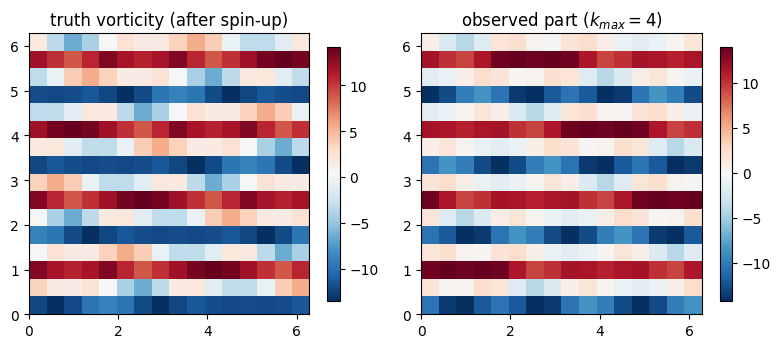

In [2]:
xx, yy = model.grid()
x = model.to_spectral_state(model.kolmogorov_vorticity(mode=4) + 0.1 * np.sin(xx + yy))
for _ in range(spinup):
    x = step(x, Dt)
truth = [x]
for _ in range(cycles):
    truth.append(step(truth[-1], Dt))
truth = np.asarray(truth)
t = np.arange(cycles + 1) * Dt

obs_op = model.spectral_low_mode_observation(kmax=kmax_obs)
H = obs_op.as_matrix()
R = np.diag(obs_op.observation_variances(sigma0=sigma0, decay_power=1.0))
y = np.stack([H @ xt for xt in truth])
y += rng.multivariate_normal(np.zeros(obs_op.obs_dim), R, size=len(y))
print(f"state dim: {model.spectral_state_dim}, obs dim: {obs_op.obs_dim}")

omega_truth0 = model.from_spectral_state(truth[0])
fig, axes = plt.subplots(1, 2, figsize=(8, 3.4))
for ax, field, title in (
    (axes[0], omega_truth0, "truth vorticity (after spin-up)"),
    (axes[1], model.project_low_modes(omega_truth0, kmax_obs), f"observed part ($k_{{max}}={kmax_obs}$)"),
):
    im = ax.imshow(field, origin="lower", cmap="RdBu_r", extent=[0, 2 * np.pi, 0, 2 * np.pi])
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.85)
fig.tight_layout()

## 7. Assimilation results

The vorticity snapshots compare truth, analysis mean, and their difference
at the middle and the end of the assimilation period.

In [3]:
X0 = truth[0] + 0.5 * rng.standard_normal((m, model.spectral_state_dim))
filt = ETKF(step, H, R, alpha=alpha)
filt.initialize(X0)

means = [filt.X.mean(axis=0)]
rmses = [float(loss_rms(means[0], truth[0]))]
for k in range(1, cycles + 1):
    filt.forecast(Dt)
    filt.update(y[k])
    means.append(filt.X.mean(axis=0))
    rmses.append(float(loss_rms(means[-1], truth[k])))
means, rmses = np.asarray(means), np.asarray(rmses)

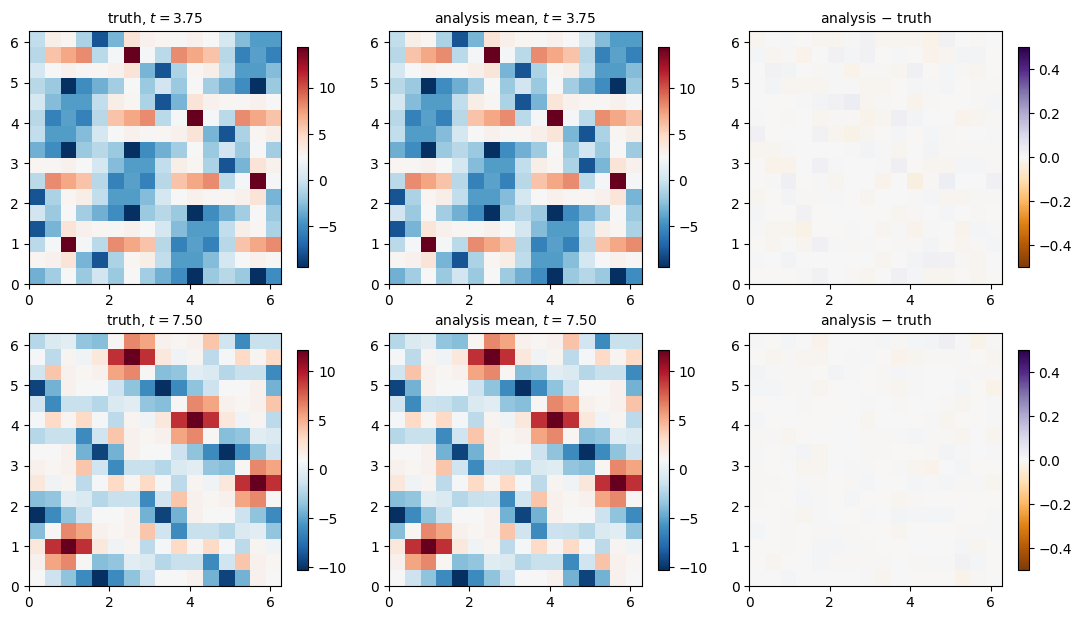

In [4]:
snap = [cycles // 2, cycles]
fig, axes = plt.subplots(2, 3, figsize=(11, 6.2))
for row, k in enumerate(snap):
    w_true = model.from_spectral_state(truth[k])
    w_anl = model.from_spectral_state(means[k])
    for col, (field, title, (vmin, vmax), cmap) in enumerate((
        (w_true, f"truth, $t={t[k]:.2f}$", (None, None), "RdBu_r"),
        (w_anl, f"analysis mean, $t={t[k]:.2f}$", (None, None), "RdBu_r"),
        (w_anl - w_true, "analysis $-$ truth", (-0.5, 0.5), "PuOr"),
    )):
        ax = axes[row, col]
        im = ax.imshow(field, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax,
                       extent=[0, 2 * np.pi, 0, 2 * np.pi])
        ax.set_title(title, fontsize=10)
        fig.colorbar(im, ax=ax, shrink=0.85)
fig.tight_layout()

## 8. RMSE

Spectral-state analysis RMSE (`da.loss.loss_rms`, equivalent to the common
definition of `docs/notebook_spec.md`) against
$\sigma_{\mathrm{obs}} = \sqrt{\operatorname{tr}(R)/N_y}$.

observation noise scale: 0.178
mean RMSE (2nd half): 0.091


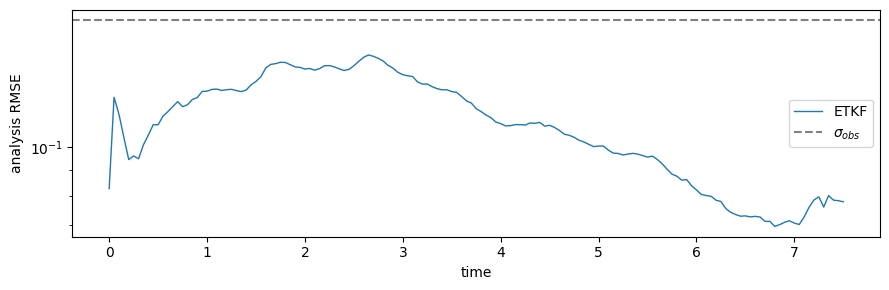

In [5]:
sigma_obs = np.sqrt(np.trace(R) / R.shape[0])
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t, rmses, color="tab:blue", lw=1, label="ETKF")
ax.set_yscale("log")
ax.axhline(sigma_obs, color="gray", ls="--", label=r"$\sigma_{obs}$")
ax.set_xlabel("time")
ax.set_ylabel("analysis RMSE")
ax.legend()
fig.tight_layout()

half = cycles // 2
print(f"observation noise scale: {sigma_obs:.3f}")
print(f"mean RMSE (2nd half): {rmses[half:].mean():.3f}")

## 9. Summary

Although only 81 of 256 spectral components are observed, the ETKF with
$m = 32$ members drives the analysis RMSE to roughly $0.09$, about half
the observation-noise scale $\sigma_{\mathrm{obs}} \approx 0.18$: the
dissipative dynamics ($\nu = 10^{-2}$, $\gamma = 10^{-1}$) contract the
unobserved high-wavenumber error while the low-mode observations control
the large scales. Stronger turbulence (smaller $\nu$) or fewer observed
modes require larger ensembles — see the archived large-ensemble studies
referenced in `docs/archive_audit.md`.